In [80]:
# =============================================================================
# hydro_diagnostic.ipynb
# Diagnostic notebook for the 2024 hydro seasonality discrepancy
# =============================================================================

In [81]:
# --- Cell 1: Setup ---

import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

NETWORK_PATH = "/Users/fowfloi/Documents/pypsa-earth/results/nigeria_2024_validation/networks/elec_s_10_ec_lv1.0_1h.nc"
TCN_PATH = "/Users/fowfloi/Documents/PHD_Program/PHD_program/Year 2/Papaer 1 workplan/Paper_1_thesis/Data/Processed/nigeria_generation_final.csv"

n = pypsa.Network(NETWORK_PATH)

# Isolate the connected grid. NG1 0 is the OSM-derived isolated bus you
# identified during validation, so it is excluded from all dispatch summaries.
n.determine_network_topology()
main_sub = n.buses.sub_network.mode()[0]
connected = n.buses.index[n.buses.sub_network == main_sub].tolist()

connected_gens = n.generators[n.generators.bus.isin(connected)].index
connected_loads = [c for c in n.loads_t.p_set.columns if c in connected]

print(f"Network loaded: {len(n.snapshots)} snapshots, "
      f"{len(connected)} connected buses, "
      f"{len(connected_gens)} connected generators")
print(f"Excluded buses: {[b for b in n.buses.index if b not in connected]}")

INFO:pypsa.io:Imported network elec_s_10_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


Network loaded: 8784 snapshots, 9 connected buses, 36 connected generators
Excluded buses: ['NG1 0']


In [82]:
# --- Cell 2: Load TCN and build monthly series ---

tcn_raw = pd.read_csv(TCN_PATH, parse_dates=["datetime"])
tcn_raw = tcn_raw[tcn_raw.datetime.dt.year == 2024].set_index("datetime")

hydro_cols = ["KAINJI", "JEBBA", "SHIRORO", "DADIN KOWA", "ZUNGERU", "KASHAMBILLA"]

for c in tcn_raw.columns:
    tcn_raw[c] = pd.to_numeric(tcn_raw[c], errors="coerce")

tcn_hydro_monthly = tcn_raw[hydro_cols].sum(axis=1).resample("ME").sum() / 1e6  # TWh

# Model monthly hydro, from storage dispatch only. Hydro in the model is a
# storage unit, not a generator, so p_dispatch is the right series.
model_hydro_hourly = n.storage_units_t.p_dispatch[
    n.storage_units[n.storage_units.carrier == "hydro"].index
].sum(axis=1).clip(lower=0)

model_hydro_monthly = model_hydro_hourly.resample("ME").sum() / 1e6

# Model monthly inflow, from the storage units
model_inflow_monthly = n.storage_units_t.inflow.sum(axis=1).resample("ME").sum() / 1e6

comparison = pd.DataFrame({
    "TCN_hydro_TWh": tcn_hydro_monthly.values,
    "Model_hydro_TWh": model_hydro_monthly.values,
    "Model_inflow_TWh": model_inflow_monthly.values,
}, index=[d.strftime("%b") for d in tcn_hydro_monthly.index])

print(comparison.round(3).to_string())
print(f"\nAnnual totals:")
print(f"  TCN hydro      : {comparison.TCN_hydro_TWh.sum():.3f} TWh")
print(f"  Model hydro    : {comparison.Model_hydro_TWh.sum():.3f} TWh")
print(f"  Model inflow   : {comparison.Model_inflow_TWh.sum():.3f} TWh")
print(f"\nCorrelation model hydro vs TCN hydro  : "
      f"{comparison.TCN_hydro_TWh.corr(comparison.Model_hydro_TWh):.3f}")
print(f"Correlation model hydro vs model inflow: "
      f"{comparison.Model_hydro_TWh.corr(comparison.Model_inflow_TWh):.3f}")

     TCN_hydro_TWh  Model_hydro_TWh  Model_inflow_TWh
Jan          0.777            0.443             0.118
Feb          0.736            0.456             0.061
Mar          0.754            0.467             0.045
Apr          0.666            0.457             0.033
May          0.875            0.411             0.043
Jun          0.782            0.423             0.079
Jul          0.950            0.853             1.731
Aug          1.033            1.295             3.148
Sep          0.971            1.269             3.964
Oct          0.966            1.193             1.886
Nov          0.946            0.700             0.715
Dec          1.018            0.484             0.363

Annual totals:
  TCN hydro      : 10.474 TWh
  Model hydro    : 8.451 TWh
  Model inflow   : 12.188 TWh

Correlation model hydro vs TCN hydro  : 0.697
Correlation model hydro vs model inflow: 0.955


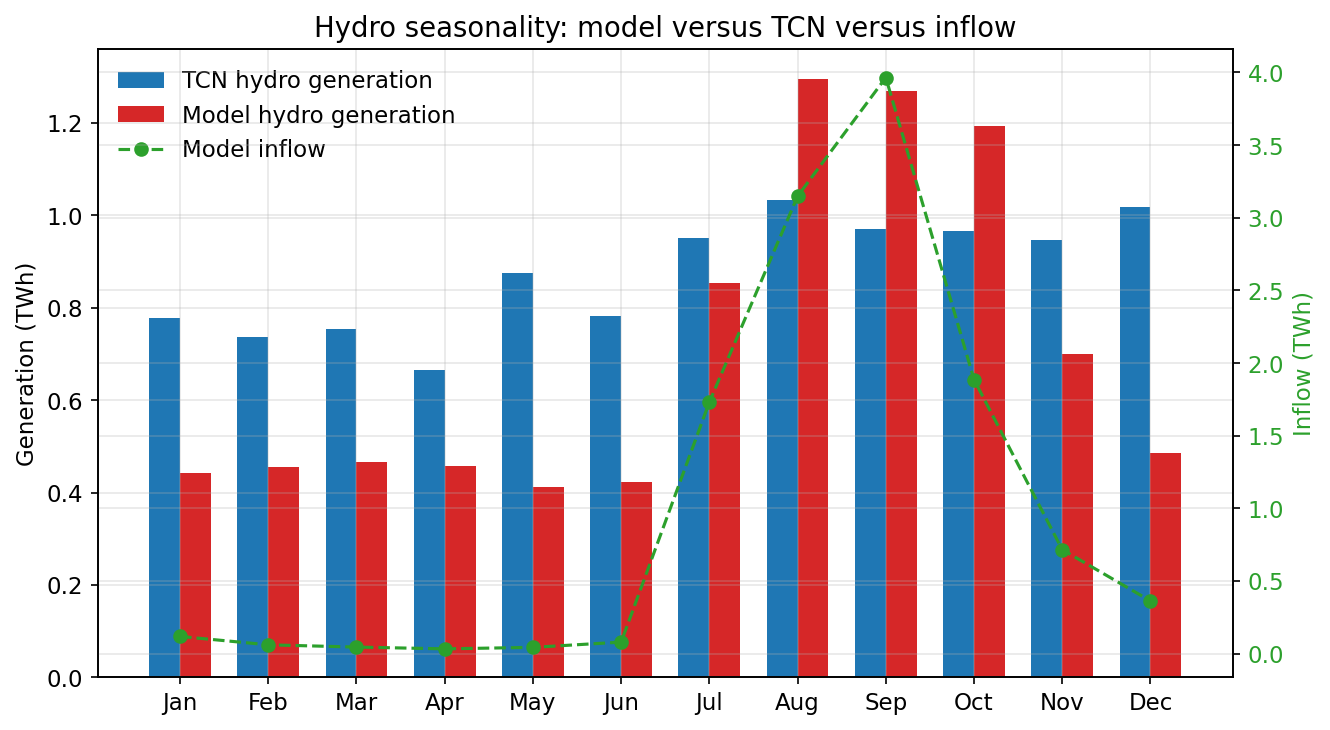

In [83]:
# --- Cell 3: The diagnostic three series plot ---

months = comparison.index.tolist()

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

x = np.arange(len(months))
width = 0.35

# Generation on the left axis
ax1.bar(x - width/2, comparison.TCN_hydro_TWh, width,
        label="TCN hydro generation", color="#1f77b4")
ax1.bar(x + width/2, comparison.Model_hydro_TWh, width,
        label="Model hydro generation", color="#d62728")

# Inflow on the right axis, as a line and marker overlay
ax2.plot(x, comparison.Model_inflow_TWh, "o--", color="#2ca02c",
         lw=1.5, label="Model inflow")
ax2.set_ylabel("Inflow (TWh)", color="#2ca02c")
ax2.tick_params(axis="y", labelcolor="#2ca02c")

ax1.set_xticks(x)
ax1.set_xticklabels(months)
ax1.set_ylabel("Generation (TWh)")
ax1.set_title("Hydro seasonality: model versus TCN versus inflow")

# Combine legends
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig("fig_hydro_diagnostic_three_series.png", bbox_inches="tight")
plt.show()

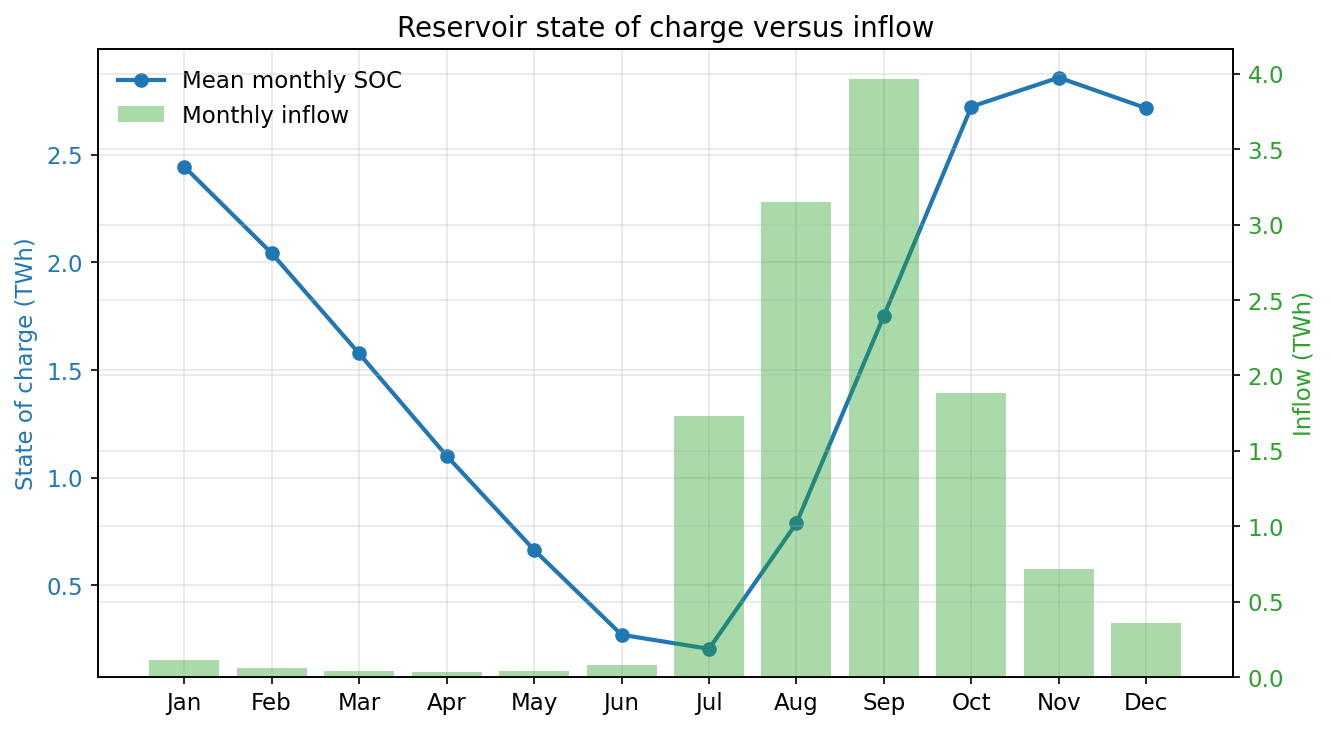

Monthly SOC (TWh) and inflow (TWh):
     SOC_TWh  inflow_TWh
Jan    2.446       0.118
Feb    2.043       0.061
Mar    1.577       0.045
Apr    1.102       0.033
May    0.664       0.043
Jun    0.269       0.079
Jul    0.204       1.731
Aug    0.788       3.148
Sep    1.753       3.964
Oct    2.725       1.886
Nov    2.860       0.715
Dec    2.717       0.363


In [84]:
# --- Cell 4: Monthly mean SOC and inflow ---

soc_monthly = n.storage_units_t.state_of_charge.sum(axis=1).resample("ME").mean() / 1e6
inflow_monthly = n.storage_units_t.inflow.sum(axis=1).resample("ME").sum() / 1e6

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.plot(range(1, 13), soc_monthly.values, "o-", color="#1f77b4",
         lw=2, label="Mean monthly SOC")
ax1.set_ylabel("State of charge (TWh)", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")

ax2.bar(range(1, 13), inflow_monthly.values, color="#2ca02c", alpha=0.4,
        label="Monthly inflow")
ax2.set_ylabel("Inflow (TWh)", color="#2ca02c")
ax2.tick_params(axis="y", labelcolor="#2ca02c")

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([d.strftime("%b") for d in soc_monthly.index])
ax1.set_title("Reservoir state of charge versus inflow")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig("fig_hydro_soc_vs_inflow.png", bbox_inches="tight")
plt.show()

print("Monthly SOC (TWh) and inflow (TWh):")
print(pd.DataFrame({
    "SOC_TWh": soc_monthly.values,
    "inflow_TWh": inflow_monthly.values,
}, index=[d.strftime("%b") for d in soc_monthly.index]).round(3).to_string())

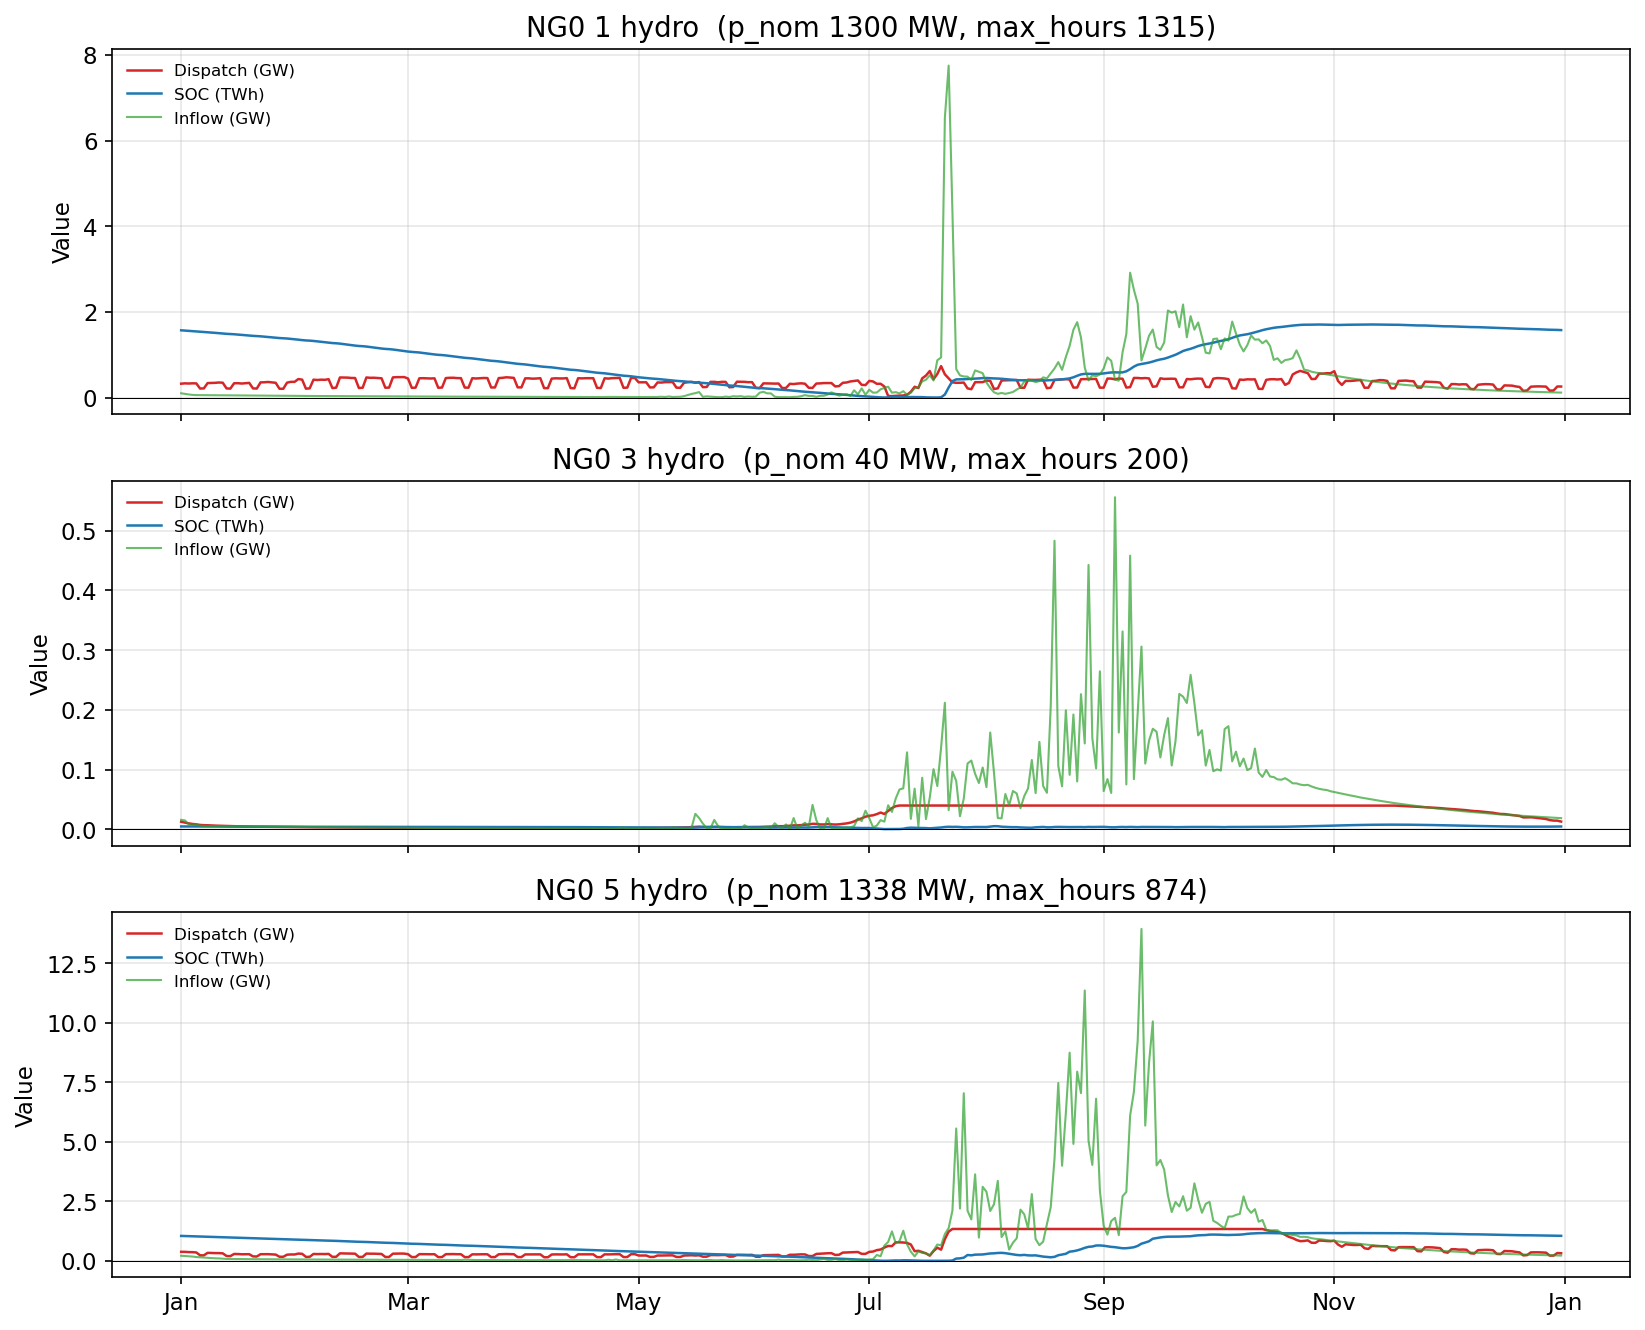

In [85]:
# --- Cell 5: Daily reservoir trajectories ---

hydro_units = n.storage_units[n.storage_units.carrier == "hydro"]

fig, axes = plt.subplots(len(hydro_units), 1, figsize=(11, 3 * len(hydro_units)),
                         sharex=True)

if len(hydro_units) == 1:
    axes = [axes]

for ax, (name, unit) in zip(axes, hydro_units.iterrows()):
    daily_p = n.storage_units_t.p_dispatch[name].resample("D").mean() / 1e3
    daily_soc = n.storage_units_t.state_of_charge[name].resample("D").mean() / 1e6
    daily_inflow = n.storage_units_t.inflow[name].resample("D").mean() / 1e3

    ax.plot(daily_p.index, daily_p, color="#d62728", lw=1.2,
            label="Dispatch (GW)")
    ax.plot(daily_soc.index, daily_soc, color="#1f77b4", lw=1.2,
            label="SOC (TWh)")
    ax.plot(daily_inflow.index, daily_inflow, color="#2ca02c", lw=1.0,
            alpha=0.7, label="Inflow (GW)")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(f"{name}  (p_nom {unit.p_nom:.0f} MW, "
                 f"max_hours {unit.max_hours:.0f})")
    ax.set_ylabel("Value")
    ax.legend(loc="upper left", frameon=False, fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.savefig("fig_hydro_per_reservoir_daily.png", bbox_inches="tight")
plt.show()

In [86]:
# --- Cell 6: Spillage check ---

if hasattr(n.storage_units_t, "spill"):
    spill_monthly = n.storage_units_t.spill.sum(axis=1).resample("ME").sum() / 1e6
    print("Monthly spillage (TWh):")
    print(spill_monthly.rename(lambda x: x.strftime("%b")).round(4).to_string())
    print(f"\nAnnual spillage: {spill_monthly.sum():.4f} TWh")
else:
    print("No spill attribute available on this network.")

# Also check the initial and final SOC settings, which are often the
# binding constraint on annual hydro behaviour in a one year run.
print("\nStorage unit parameters:")
cols = [c for c in ["p_nom", "max_hours", "state_of_charge_initial",
                    "state_of_charge_initial_per_period",
                    "state_of_charge_spillover", "cyclic_state_of_charge",
                    "efficiency_store", "efficiency_dispatch",
                    "inflow" ] if c in n.storage_units.columns]
print(n.storage_units[cols].to_string())

# The total energy capacity, which is the binding limit on seasonal
# shifting
if "max_hours" in n.storage_units.columns:
    print("\nEnergy capacity (MWh):")
    print((n.storage_units.p_nom * n.storage_units.max_hours).round(0).to_string())

Monthly spillage (TWh):
snapshot
Jan    0.0000
Feb    0.0000
Mar    0.0000
Apr    0.0000
May    0.0000
Jun    0.0000
Jul    0.1040
Aug    1.2394
Sep    1.3595
Oct    0.0930
Nov    0.0017
Dec    0.0000

Annual spillage: 2.7976 TWh

Storage unit parameters:
              p_nom    max_hours  state_of_charge_initial  state_of_charge_initial_per_period  cyclic_state_of_charge  efficiency_store  efficiency_dispatch  inflow
StorageUnit                                                                                                                                                         
NG0 1 hydro  1300.0  1315.384615                      0.0                               False                    True               0.0                  0.9     0.0
NG0 3 hydro    40.0   200.000000                      0.0                               False                    True               0.0                  0.9     0.0
NG0 5 hydro  1338.0   873.617339                      0.0                           

In [87]:
# --- Cell 7: SOC utilization ---

soc_hourly = n.storage_units_t.state_of_charge.sum(axis=1)
energy_cap = (n.storage_units.p_nom * n.storage_units.max_hours).sum()

print(f"Total energy capacity       : {energy_cap/1e6:.3f} TWh")
print(f"Peak SOC during year        : {soc_hourly.max()/1e6:.3f} TWh")
print(f"Minimum SOC during year     : {soc_hourly.min()/1e6:.3f} TWh")
print(f"Mean SOC                    : {soc_hourly.mean()/1e6:.3f} TWh")
print(f"Peak SOC / energy capacity  : {soc_hourly.max()/energy_cap:.2f}")
print(f"Min SOC / energy capacity   : {soc_hourly.min()/energy_cap:.2f}")

print(f"\nAnnual inflow               : {n.storage_units_t.inflow.sum().sum()/1e6:.3f} TWh")
print(f"Annual dispatch             : {model_hydro_hourly.sum()/1e6:.3f} TWh")
print(f"Inflow / energy capacity    : "
      f"{n.storage_units_t.inflow.sum().sum()/energy_cap:.1f}x")

Total energy capacity       : 2.887 TWh
Peak SOC during year        : 2.887 TWh
Minimum SOC during year     : 0.003 TWh
Mean SOC                    : 1.594 TWh
Peak SOC / energy capacity  : 1.00
Min SOC / energy capacity   : 0.00

Annual inflow               : 12.188 TWh
Annual dispatch             : 8.451 TWh
Inflow / energy capacity    : 4.2x


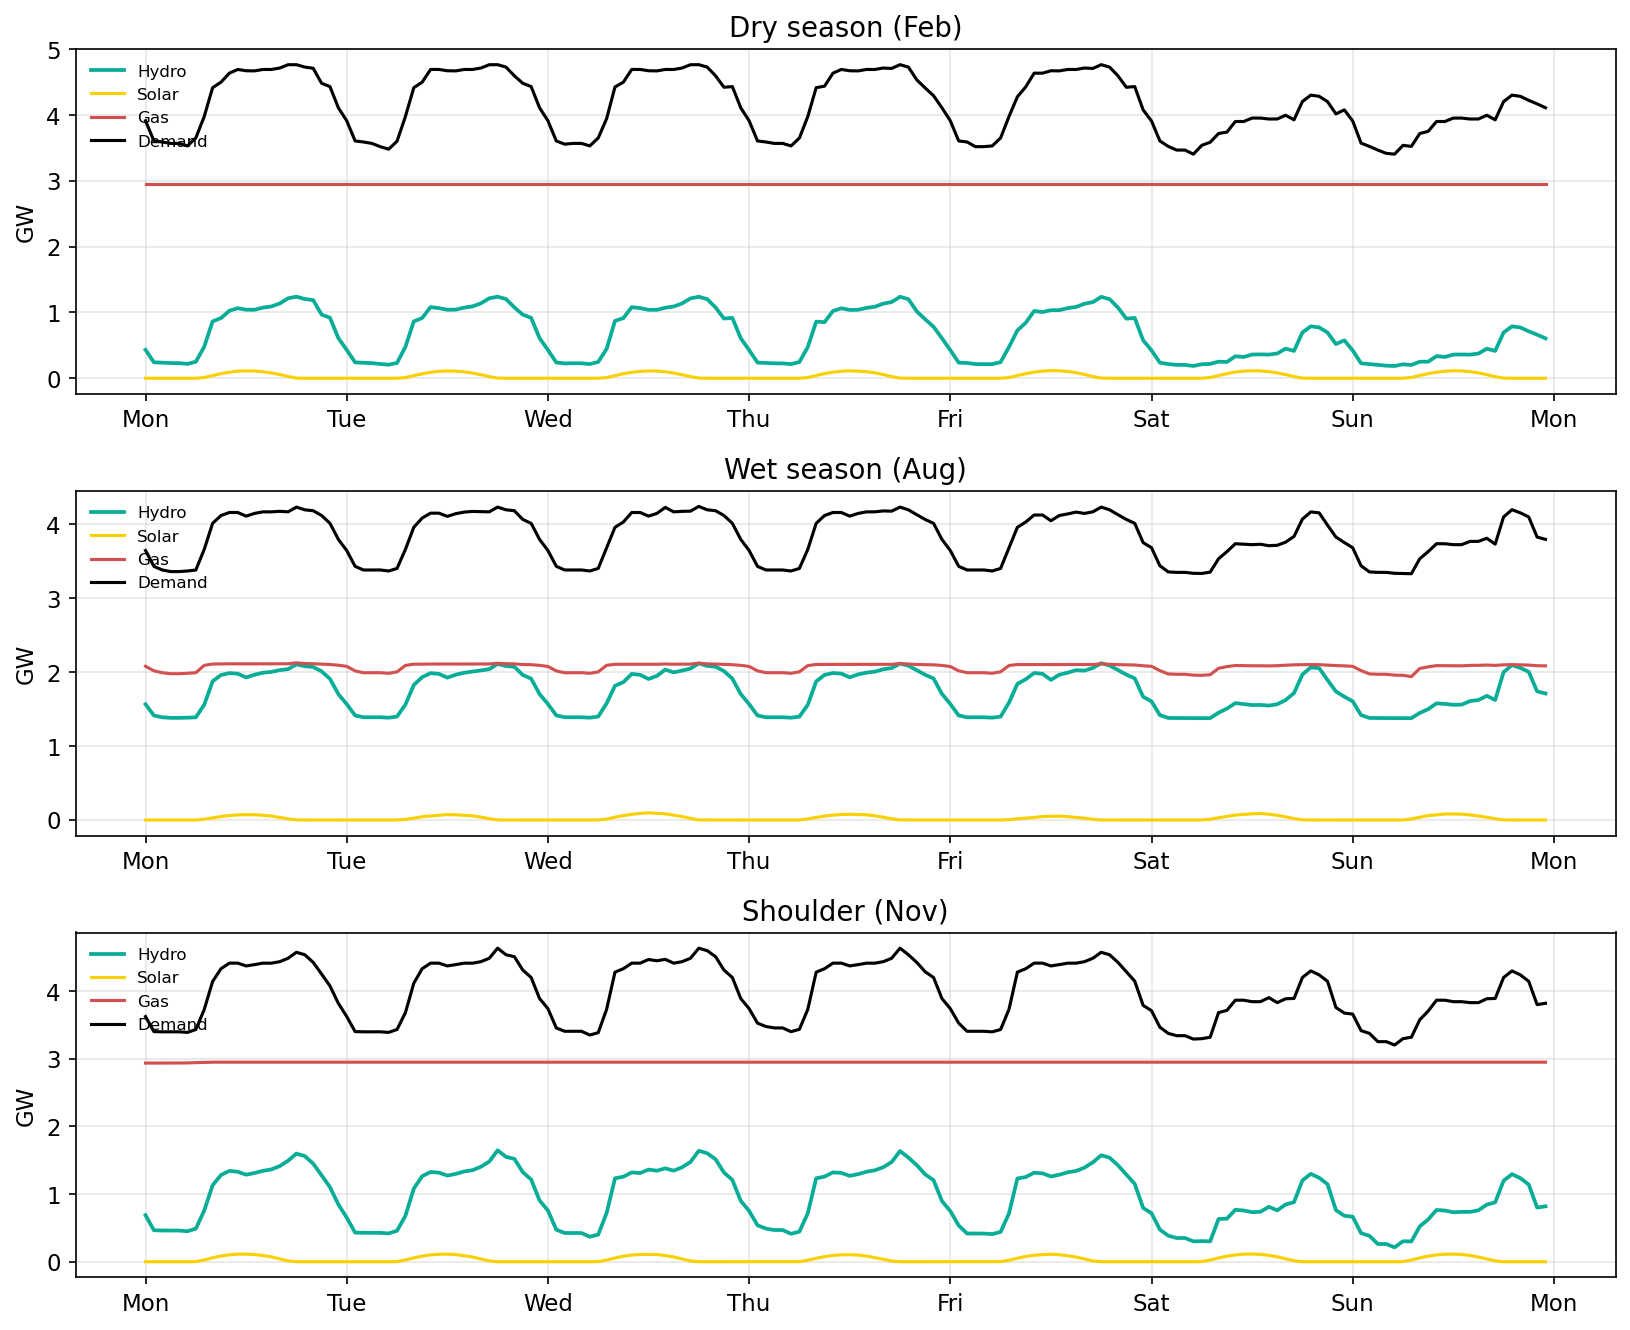

In [88]:
# --- Cell 8: Hourly dispatch in selected weeks ---

weeks = {
    "Dry season (Feb)": ("2024-02-12", "2024-02-18"),
    "Wet season (Aug)": ("2024-08-12", "2024-08-18"),
    "Shoulder (Nov)": ("2024-11-11", "2024-11-17"),
}

hydro_total = n.storage_units_t.p_dispatch[
    n.storage_units[n.storage_units.carrier == "hydro"].index
].sum(axis=1).clip(lower=0) / 1e3  # GW

solar_total = n.generators_t.p[
    n.generators[(n.generators.carrier == "solar") &
                 (n.generators.bus.isin(connected))].index
].sum(axis=1) / 1e3  # GW

gas_cols = n.generators[(n.generators.carrier.isin(["CCGT", "OCGT"])) &
                        (n.generators.bus.isin(connected))].index
gas_total = n.generators_t.p[gas_cols].sum(axis=1) / 1e3  # GW

load_total = n.loads_t.p_set[connected_loads].sum(axis=1) / 1e3  # GW

fig, axes = plt.subplots(len(weeks), 1, figsize=(11, 3 * len(weeks)))

for ax, (label, (start, end)) in zip(axes, weeks.items()):
    sl = slice(start, end)
    ax.plot(hydro_total.loc[sl].index, hydro_total.loc[sl],
            color="#08ad97", lw=1.8, label="Hydro")
    ax.plot(solar_total.loc[sl].index, solar_total.loc[sl],
            color="#f9d002", lw=1.5, label="Solar")
    ax.plot(gas_total.loc[sl].index, gas_total.loc[sl],
            color="#d35050", lw=1.5, label="Gas")
    ax.plot(load_total.loc[sl].index, load_total.loc[sl],
            color="black", lw=1.5, label="Demand")
    ax.set_ylabel("GW")
    ax.set_title(label)
    ax.legend(loc="upper left", frameon=False, fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a"))

plt.tight_layout()
plt.savefig("fig_hydro_hourly_weeks.png", bbox_inches="tight")
plt.show()

In [89]:
# --- Cell 9: Unit capacity inflow vs dispatch ---

total_hydro_cap = n.storage_units[n.storage_units.carrier == "hydro"].p_nom.sum() / 1e3

inflow_per_gw = inflow_monthly / total_hydro_cap
dispatch_per_gw = model_hydro_monthly / total_hydro_cap

summary = pd.DataFrame({
    "inflow_GWh_per_GW": inflow_per_gw.values * 1e3,
    "dispatch_GWh_per_GW": dispatch_per_gw.values * 1e3,
}, index=[d.strftime("%b") for d in inflow_monthly.index])

summary["utilization"] = summary.dispatch_GWh_per_GW / summary.inflow_GWh_per_GW
print(summary.round(3).to_string())
print(f"\nAnnual utilization of inflow: "
      f"{summary.dispatch_GWh_per_GW.sum() / summary.inflow_GWh_per_GW.sum():.3f}")

     inflow_GWh_per_GW  dispatch_GWh_per_GW  utilization
Jan             44.240              165.256        3.735
Feb             22.702              170.302        7.502
Mar             16.878              174.277       10.326
Apr             12.325              170.673       13.848
May             16.156              153.488        9.500
Jun             29.666              158.104        5.329
Jul            646.442              318.375        0.493
Aug           1175.373              483.485        0.411
Sep           1480.376              474.004        0.320
Oct            704.265              445.390        0.632
Nov            267.156              261.507        0.979
Dec            135.460              180.893        1.335

Annual utilization of inflow: 0.693


In [90]:
# --- Cell 10: Mass balance check on the reservoir ---

# Verify that dSOC/dt = inflow - dispatch - spillage
soc_hourly_total = n.storage_units_t.state_of_charge.sum(axis=1)
inflow_hourly = n.storage_units_t.inflow.sum(axis=1)
dispatch_hourly = n.storage_units_t.p_dispatch[
    n.storage_units[n.storage_units.carrier == "hydro"].index
].sum(axis=1).clip(lower=0)

if hasattr(n.storage_units_t, "spill"):
    spill_hourly = n.storage_units_t.spill.sum(axis=1)
else:
    spill_hourly = pd.Series(0, index=soc_hourly_total.index)

dsoc = soc_hourly_total.diff()
residual = inflow_hourly - dispatch_hourly - spill_hourly

# Align and compare
mass_balance = pd.DataFrame({
    "dSOC": dsoc,
    "inflow_minus_dispatch_minus_spill": residual.shift(1),
}).dropna()

print("Mass balance check (should be near zero):")
print(f"  Mean residual: {(mass_balance.dSOC - mass_balance.inflow_minus_dispatch_minus_spill).mean():.4f} MWh")
print(f"  Std residual:  {(mass_balance.dSOC - mass_balance.inflow_minus_dispatch_minus_spill).std():.4f} MWh")

# Monthly aggregated
monthly_mb = mass_balance.resample("ME").sum() / 1e6
monthly_mb["month"] = monthly_mb.index.strftime("%b")
print("\nMonthly mass balance (TWh):")
print(monthly_mb[["dSOC", "inflow_minus_dispatch_minus_spill"]].round(3).to_string())

Mass balance check (should be near zero):
  Mean residual: -106.8410 MWh
  Std residual:  646.7767 MWh

Monthly mass balance (TWh):
             dSOC  inflow_minus_dispatch_minus_spill
snapshot                                            
2024-01-31 -0.372                             -0.324
2024-02-29 -0.445                             -0.395
2024-03-31 -0.472                             -0.422
2024-04-30 -0.474                             -0.424
2024-05-31 -0.412                             -0.368
2024-06-30 -0.390                             -0.344
2024-07-31  0.678                              0.772
2024-08-31  0.468                              0.615
2024-09-30  1.191                              1.333
2024-10-31  0.466                              0.602
2024-11-30 -0.064                              0.013
2024-12-31 -0.175                             -0.122


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - formulation: kirchhoff
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 11.80it/s]
INFO:linopy.io: Writing time: 3.27s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2778575


INFO:gurobipy:Set parameter LicenseID to value 2778575


...

INFO:gurobipy:Read LP format model from file /private/var/folders/q6/hs8yrk9j6hb8hp1m41xhqhmr0000gn/T/linopy-problem-frlb96bm.lp


Reading time = 1.22 seconds


INFO:gurobipy:Reading time = 1.22 seconds


obj: 1150704 rows, 535824 columns, 1774368 nonzeros


INFO:gurobipy:obj: 1150704 rows, 535824 columns, 1774368 nonzeros


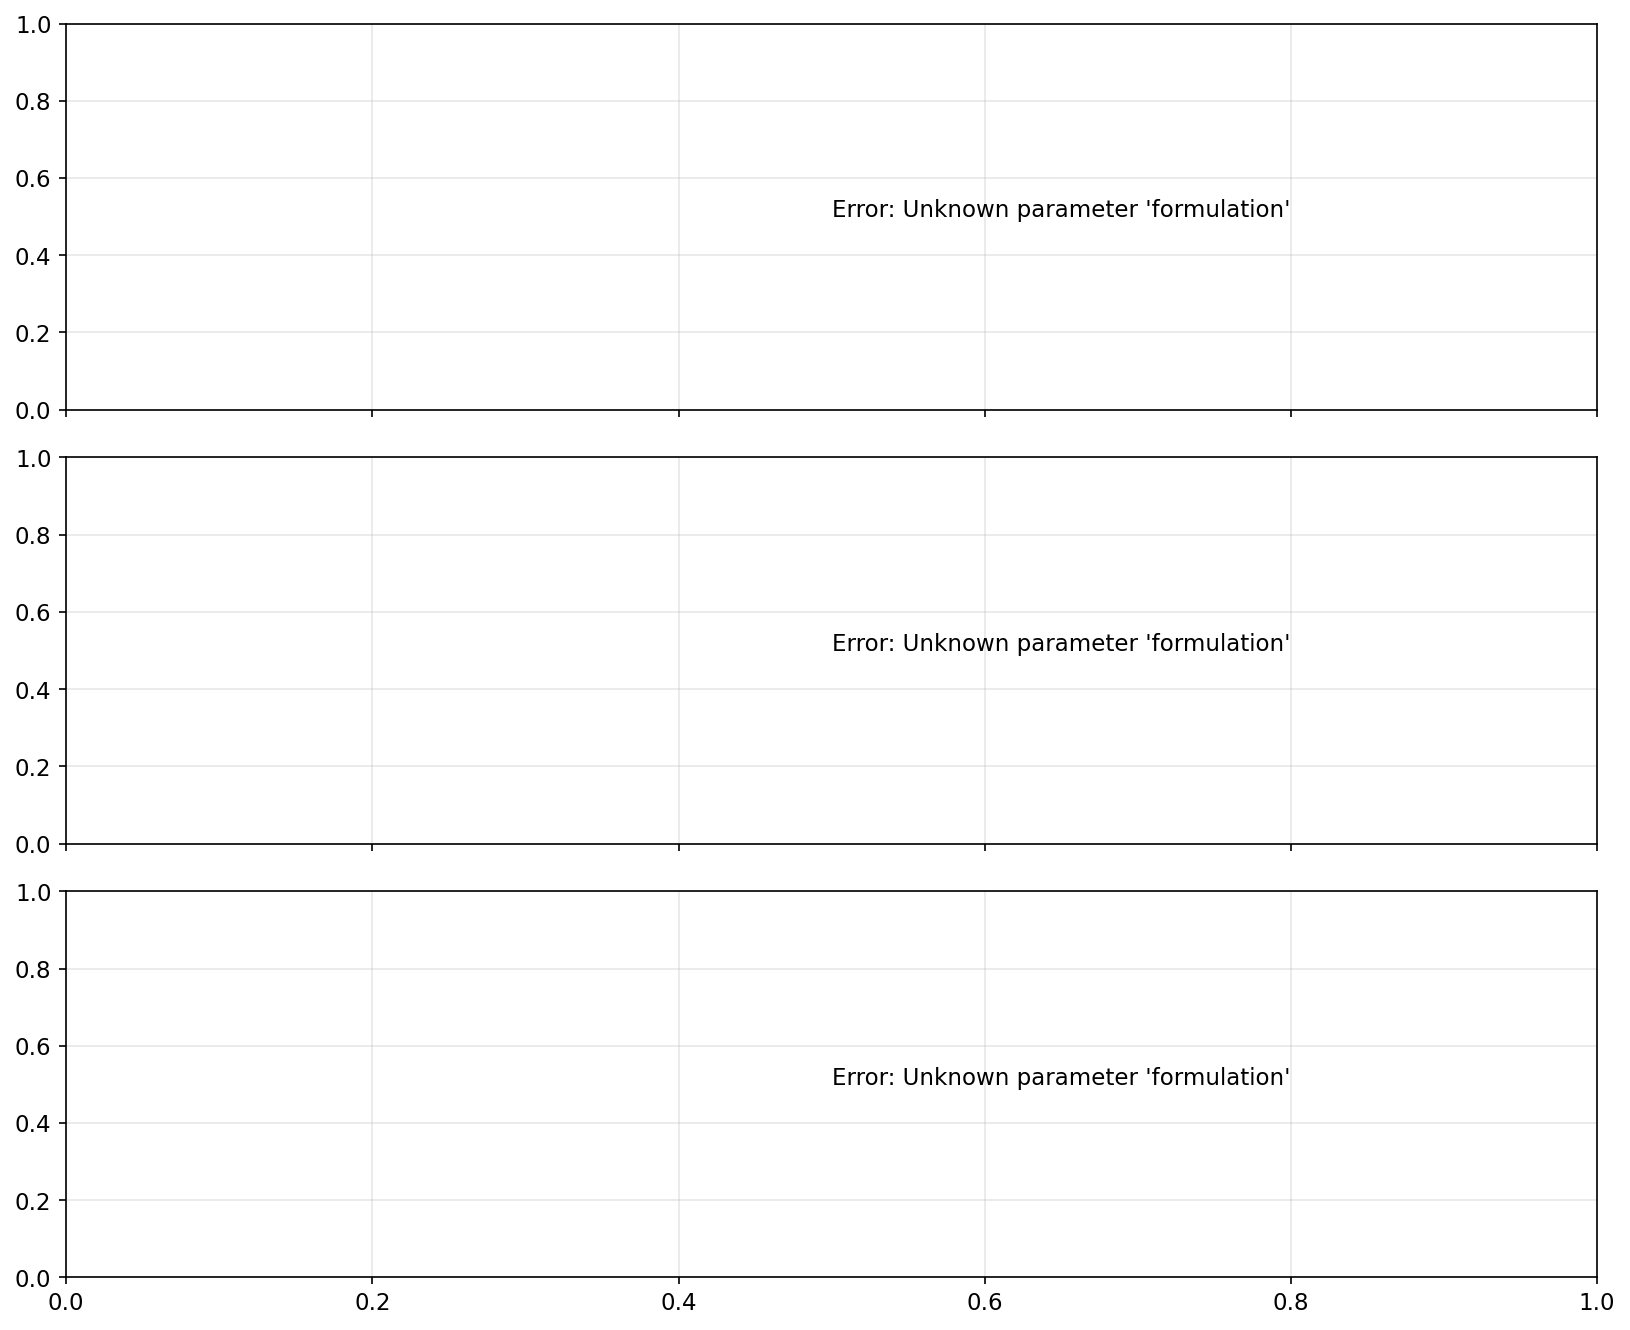

In [91]:
# --- Cell 11: Test the max_hours counterfactual ---

# If the reservoir were smaller (realistic live storage),
# would the dispatch shape correct?

import copy

test_hours = [4707, 500, 200]  # current, realistic Kainji, run-of-river-ish

fig, axes = plt.subplots(len(test_hours), 1, figsize=(11, 3 * len(test_hours)),
                         sharex=True)

for ax, hours in zip(axes, test_hours):
    # Create a copy and modify max_hours for the largest reservoir
    n_test = copy.deepcopy(n)
    # Scale all hydro max_hours proportionally
    hydro_mask = n_test.storage_units.carrier == "hydro"
    original_hours = n_test.storage_units.loc[hydro_mask, "max_hours"].copy()
    n_test.storage_units.loc[hydro_mask, "max_hours"] = hours

    # Re-run optimization (this assumes the network is set up for re-optimization)
    # If you have a separate solve function, call it here
    try:
        status, condition = n_test.optimize(
            solver_name="gurobi",  # or "glpk", "cbc"
            multi_investment_periods=False,
            formulation="kirchhoff",
        )
        if status == "ok":
            dispatch_test = n_test.storage_units_t.p_dispatch[
                n_test.storage_units[n_test.storage_units.carrier == "hydro"].index
            ].sum(axis=1).clip(lower=0).resample("ME").sum() / 1e6
            ax.plot(range(1, 13), dispatch_test.values, "o-", label=f"max_hours={hours}")
            ax.plot(range(1, 13), tcn_hydro_monthly.values, "s--", label="TCN observed", color="black")
            ax.set_ylabel("TWh")
            ax.set_title(f"max_hours = {hours} h")
            ax.legend()
            ax.set_xticks(range(1, 13))
            ax.set_xticklabels([d.strftime("%b") for d in dispatch_test.index])
        else:
            ax.text(0.5, 0.5, f"Solve failed: {condition}", transform=ax.transAxes)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {e}", transform=ax.transAxes)

plt.tight_layout()
plt.savefig("fig_hydro_max_hours_test.png", bbox_inches="tight")
plt.show()

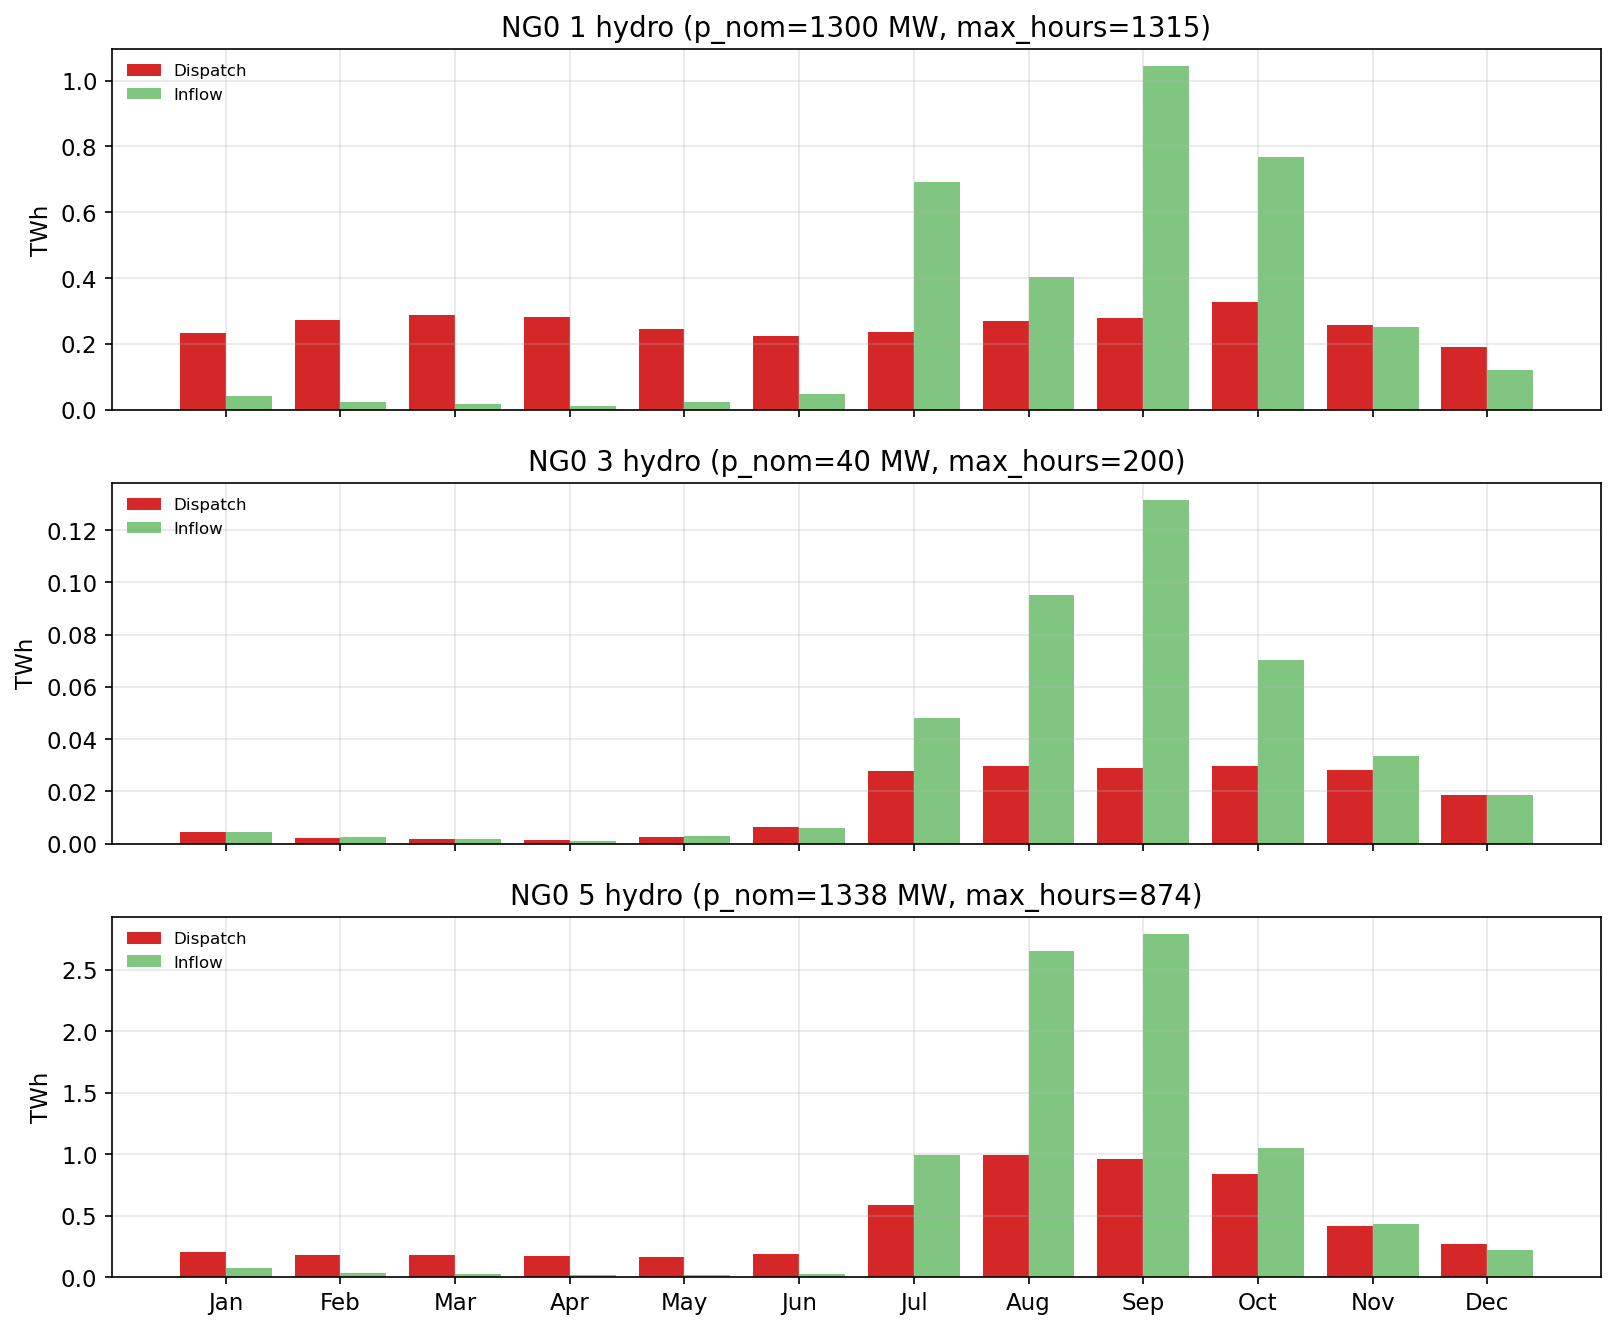

In [92]:
# --- Cell 12: Per-plant hydro decomposition ---

# Separate the hydro units and compare their dispatch patterns

hydro_units = n.storage_units[n.storage_units.carrier == "hydro"]

fig, axes = plt.subplots(len(hydro_units), 1, figsize=(11, 3 * len(hydro_units)),
                         sharex=True)
if len(hydro_units) == 1:
    axes = [axes]

for ax, (name, unit) in zip(axes, hydro_units.iterrows()):
    monthly_p = n.storage_units_t.p_dispatch[name].clip(lower=0).resample("ME").sum() / 1e6
    monthly_inflow = n.storage_units_t.inflow[name].resample("ME").sum() / 1e6

    x = range(1, 13)
    ax.bar([i - 0.2 for i in x], monthly_p.values, width=0.4,
           label="Dispatch", color="#d62728")
    ax.bar([i + 0.2 for i in x], monthly_inflow.values, width=0.4,
           label="Inflow", color="#2ca02c", alpha=0.6)
    ax.set_ylabel("TWh")
    ax.set_title(f"{name} (p_nom={unit.p_nom:.0f} MW, max_hours={unit.max_hours:.0f})")
    ax.legend(loc="upper left", frameon=False, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([d.strftime("%b") for d in monthly_p.index])

plt.tight_layout()
plt.savefig("fig_hydro_per_plant_monthly.png", bbox_inches="tight")
plt.show()

In [93]:
# --- Cell 13: Efficiency parameter diagnostic ---

# Check what PyPSA is doing with efficiency_store = 0.0

print("Storage unit efficiency parameters:")
print(n.storage_units[["efficiency_store", "efficiency_dispatch",
                        "standing_loss"]].to_string())

# Compute the implied standing loss per hour
# If efficiency_store = 0.0, PyPSA may treat this as no loss (perverse)
# or as zero efficiency (would prevent storage). Check the actual behaviour:
soc = n.storage_units_t.state_of_charge
inflow = n.storage_units_t.inflow
dispatch = n.storage_units_t.p_dispatch
spill = n.storage_units_t.spill if hasattr(n.storage_units_t, "spill") else 0

# For one unit, back out the implied efficiency
unit_name = n.storage_units[n.storage_units.carrier == "hydro"].index[0]
soc_u = soc[unit_name]
inflow_u = inflow[unit_name]
dispatch_u = dispatch[unit_name].clip(lower=0)
spill_u = spill[unit_name] if hasattr(spill, "columns") else 0

# SOC[t] = SOC[t-1] * (1 - standing_loss) + inflow[t] - dispatch[t] / eff_dispatch - spill[t]
# Solve for standing_loss assuming efficiency_dispatch = 0.9
implied_loss = 1 - (soc_u.iloc[1:].values - inflow_u.iloc[1:].values
                    + dispatch_u.iloc[1:].values / 0.9 + spill_u.iloc[1:].values) / soc_u.iloc[:-1].values
implied_loss = implied_loss[np.isfinite(implied_loss) & (implied_loss > -0.1) & (implied_loss < 0.1)]

print(f"\nImplied standing loss per hour for {unit_name}:")
print(f"  Mean: {implied_loss.mean():.6f}")
print(f"  Median: {np.median(implied_loss):.6f}")
print(f"  Annualized: {(1 - (1 - np.median(implied_loss))**8760):.2%}")

Storage unit efficiency parameters:
             efficiency_store  efficiency_dispatch  standing_loss
StorageUnit                                                      
NG0 1 hydro               0.0                  0.9            0.0
NG0 3 hydro               0.0                  0.9            0.0
NG0 5 hydro               0.0                  0.9            0.0

Implied standing loss per hour for NG0 1 hydro:
  Mean: 0.000001
  Median: -0.000000
  Annualized: -0.42%


In [94]:
# Check gas dispatch variability
gas_cols = n.generators[(n.generators.carrier.isin(["CCGT", "OCGT"])) &
                        (n.generators.bus.isin(connected))].index
gas_dispatch = n.generators_t.p[gas_cols]

print("Gas dispatch statistics per plant (MW):")
print(gas_dispatch.describe().round(1).to_string())

print("\nGas dispatch variability (std / mean):")
print((gas_dispatch.std() / gas_dispatch.mean()).round(3).to_string())

# Check p_min_pu
print("\nGas plant p_min_pu values:")
print(n.generators.loc[gas_cols, "p_min_pu"].to_string())

# Check ramp limits
print("\nGas plant ramp limits:")
ramp_cols = [c for c in ["ramp_limit_up", "ramp_limit_down", "ramp_limit_start_up"] if c in n.generators.columns]
if ramp_cols:
    print(n.generators.loc[gas_cols, ramp_cols].to_string())

Gas dispatch statistics per plant (MW):
Generator  NG0 0 CCGT  NG0 0 OCGT  NG0 2 CCGT  NG0 2 OCGT  NG0 3 OCGT  NG0 4 CCGT  NG0 4 OCGT  NG0 8 CCGT  NG0 8 OCGT
count          8784.0      8784.0      8784.0      8784.0      8784.0      8784.0      8784.0      8784.0      8784.0
mean            403.9       348.9       312.1       394.0        10.8       146.9       421.2       190.9       483.2
std               4.3       218.1         3.3       168.4         1.0         1.6         5.3         2.0         5.2
min               0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0
25%             403.9         9.1       312.1       380.9        10.0       146.9       421.2       190.9       483.2
50%             403.9       489.6       312.1       490.6        11.3       146.9       421.6       190.9       483.5
75%             403.9       489.6       312.1       490.6        11.3       146.9       421.6       190.9       483.5
max             

In [95]:
print("Monthly mean demand (GW):")
print((n.loads_t.p_set[connected_loads].sum(axis=1).resample("ME").mean() / 1e3).round(2).to_string())

print("\nMonthly peak demand (GW):")
print((n.loads_t.p_set[connected_loads].sum(axis=1).resample("ME").max() / 1e3).round(2).to_string())

Monthly mean demand (GW):
snapshot
2024-01-31    4.01
2024-02-29    4.15
2024-03-31    4.13
2024-04-30    4.13
2024-05-31    3.99
2024-06-30    3.87
2024-07-31    3.82
2024-08-31    3.83
2024-09-30    3.84
2024-10-31    3.87
2024-11-30    3.96
2024-12-31    3.83
Freq: ME

Monthly peak demand (GW):
snapshot
2024-01-31    4.59
2024-02-29    4.83
2024-03-31    4.72
2024-04-30    4.67
2024-05-31    4.42
2024-06-30    4.31
2024-07-31    4.20
2024-08-31    4.24
2024-09-30    4.24
2024-10-31    4.41
2024-11-30    4.64
2024-12-31    4.41
Freq: ME
